# Predicción de ataque al corazón

Usando el dataset adjunto heart.csv con las siguientes columnas:

* age - Edad del paciente
* sex - Sexo del paciente
* cp - Tipo de dolor torácico ~ 0 = Típico Angina, 1 = Atípico Angina, 2 = Dolor que no es de angina, 3 = Asintomático
* trtbps - Presión sanguínea en reposo (en mm Hg)
* chol - Colesterol en mg/dl medido con un sensor BMI
* fbs - (Glucemia en ayunas > 120 mg/dl) ~ 1 = True, 0 = False
* restecg - Resultados del electro en reposo ~ 0 = Normal, 1 = onda ST-T normal, 2 = Hipertrofia ventrícula izquierda
* thalachh - Numero máximo de pulsaciones por segundo
* oldpeak - Depresión del segmento ST inducida por el ejercicio
* slp - Pendiente del segmento ST máxima durante el ejercicio
* caa - Número de vasos sanguíneos principales coloreados por fluoroscopia
* thall - Resultado del test de estrés de talasemia ~ (0,3)
* exng - Si la persona experimentó angina durante el ejercicio. ~ 1 = Si, 0 = No
* output - Variable objetivo. Si el individuo sufrió un infarto o no. ~ 1 = Si, 0 = No

Crear un clasificador que prediga si se está en riesgo de padecer un ataque de corazón o no.

Entregar un notebook que cargue, limpie y adapte los datos, entrene varios modelos, los evalúe y explique cual es el mejor.

Se tendrá en consideración:

Resolución de la tarea (5-6).
* Claridad (y exactitud) de las explicaciones (6-8).

Se valorará (8-10):

* Crear un interface (formulario) con ipywidgets que permita introducir los datos y entregue una respuesta (si o no).

### Librerías necesarias

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.ensemble import StackingClassifier, RandomForestClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import recall_score

### Importar el DataSet

Leemos el csv, lo guardamos en un dataset de pandas y mostramos los 10 primeros registros

In [2]:
df = pd.read_csv("heart.csv")
df.head(10)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


Creamos el mapa de calor para comprobar si hay variables muy correlaccionadas

Text(0.5, 1.0, 'Correlación de variables')

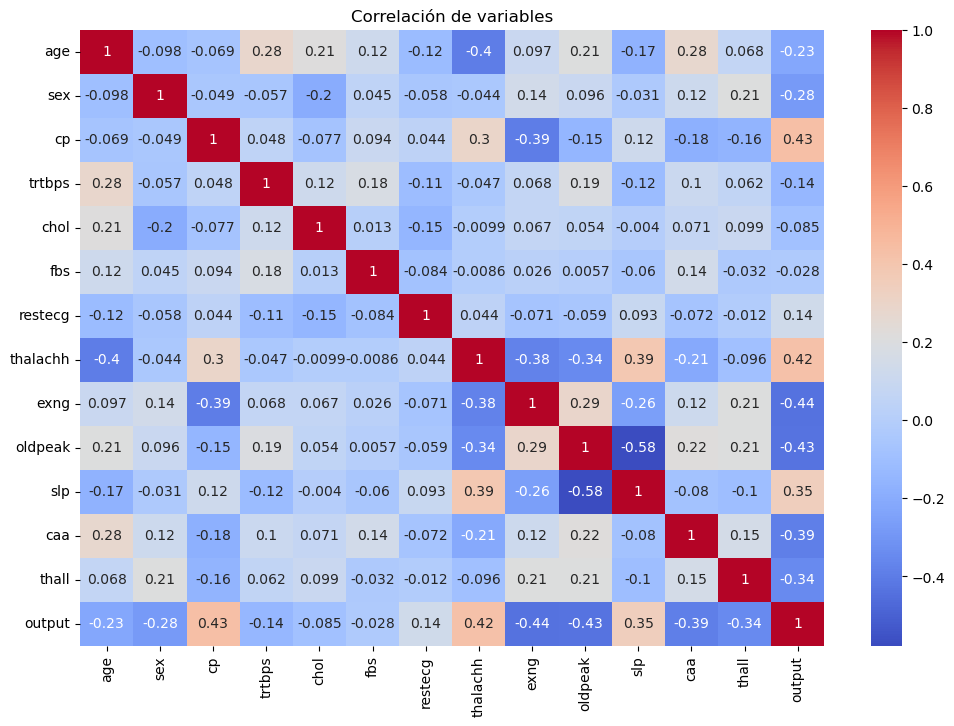

In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlación de variables")

Las variables cp y thalachh  son las que presentan las correlacciones lineales más fuertes, aunque no valoro que sean tan fuertes como para eliminar dichas características

### Preprocesado de los datos

A continuación escogemos las X o características y la variable objetivo 'output' (y)

In [3]:
X = df.drop('output', axis=1)  #caracteristicas
y = df['output']    #objetivo o target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(242, 13) (61, 13) (242,) (61,)


Creamos un Pipeline que secuencie la imputación de la media seguido de un escalado de los datos

In [ ]:
transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  #imputa la media a los valores nulos
    ('scaler', StandardScaler())    #estandarizado de los datos resta media entre desviacion tipica a cada dato
])

### Entrenamos los modelos

Vamos a utilizar 3 modelos distintos y combinarlos con un stacking

In [ ]:
#usamos un RandomForestClassifier robusto a valores atípicos, pero puede caer fácil en overfitting!
#creamos un Pipeline con el transformado de los datos y el modelo
rf = Pipeline(steps=[('pre', transformer), ('rf', RandomForestClassifier(n_estimators=100, random_state=42))]) #n_estimaators -> numero de arboles, el modelo promedia 100 decisiones distintas para reducir la varianza
rf.fit(X_train, y_train)

#el score por defecto los randomforest y de la mayoria de clasificadores es el accurracy o precision (predicciones correctas/total predicciones)
print(f"Random Forest - Accuracy: {rf.score(X_test, y_test):.4f}")
#exhaustividad, TPR
print(f"Random Forest - TPR: {recall_score(y_test, rf.predict(X_test)):.4f}")

Random Forest - Accuracy: 0.8361
Random Forest - TPR: 0.8438


In [ ]:
#SVC, busca el hhiperplano que maximize las distancias entre sanos y de riesgo, eficaz en datasets con muchas variables pero poco registros, sensible a la escala de los datos
#probability -> True, SVM solo dice Clase 0 o Clase 1, el stacking necesita probabilidades
svc = Pipeline(steps=[('pre', transformer), ('svc', SVC(probability=True, random_state=42))])
svc.fit(X_train, y_train)

#el score por defecto de svm es accurracy o precision
print(f"SVM - Accuracy: {svc.score(X_test, y_test):.4f}")
print(f"SVM - TPR: {recall_score(y_test, svc.predict(X_test)):.4f}")

SVM - Accuracy: 0.8689
SVM - TPR: 0.8438


In [ ]:
#RegresiónLogística, calcula la probabilidad de que una instancia pertenezca a la clase positiva, no trata de predecir directamente la clase
logreg = Pipeline(steps=[('pre', transformer), ('logreg', LogisticRegression())])
logreg.fit(X_train, y_train)

print(f"LogReg - Accuracy: {logreg.score(X_test, y_test):.4f}")
print(f"LogReg - TPR: {recall_score(y_test, logreg.predict(X_test)):.4f}")

LogReg - Accuracy: 0.8525
LogReg - TPR: 0.8438


El SVM es el mejor modelo con un 86.89% de aciertos totales. Esto indica que su capacidad para encontrar el hiperplano óptimo de separación entre pacientes sanos y de riesgo es superior en este dataset.

In [9]:
#para stacking usamos modelos distintos
base_models = [
    ('rf', rf),
    ('svc', svc),
    ('logreg', logreg)
]

#stacking, creamos el meta-modelo que combina las predicciones de todos
stacking_model = StackingClassifier(
    estimators=base_models,
    #el meta-modelo, mira basicamente que ha dicho el RF, EL SVM Y EL logreg y decide a quién creerle
    final_estimator=LogisticRegression(),
    #cv -> cross-validation, divide los datos en 5 trozos
    cv=5,
    n_jobs=-1  #paralelización
)

In [10]:
full_pipeline = Pipeline(steps=[
    ('preprocessor', transformer),
    ('stacking', stacking_model)
])

full_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('stacking', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str 

### Tunning de hiperparametros

Usamos GridSearchCV para buscar la combinación óptima de hiperparámetros

In [ ]:
#creamos la lista de hiperparámetros con distintos valores para cada uno
param_grid = {
    #stacking__ entra en el paso del pipeline "stacking", y dentro busca cada modelo por su nombre
    #params del rd, RandomForest
    'stacking__rf__rf__n_estimators': [100, 300, 500],
    'stacking__rf__rf__max_depth': [3, 4, 5],  #limite de "pisos" del arbol, arboles cortos, para combatir el overtting
    'stacking__rf__rf__min_samples_leaf': [5, 10],  #grupos grandes de hojas, indica cuantos pacientes deben quedar como minimo en una hoja
    
    #params del svc, SVM
    #C, regularización, c grande (100) intenta no fallar en ningun datos de entenamiento pero riesgo de overtting
    'stacking__svc__svc__C': [0.1, 1, 10, 100],
    #gamma, sclae aouto se ajutan segun el numero de variables, define cuanto alcance tiene la influencia de un solo ejemplo de entrenamiento
    'stacking__svc__svc__gamma': ['scale', 'auto', 0.01],
    
    #params del Meta-Modelo, estimador final, la regresionlogistica
    #aumentamos la regularizacion 
    'stacking__final_estimator__C': [0.1, 0.5, 1],
}

#creamos el GridSearch con 3 iteraciones de validacion cruzada y n_jobs a -1 para que pueda paralelizar el proceso
grid_stacking = GridSearchCV(full_pipeline, param_grid, cv=3, n_jobs=-1)
grid_stacking.fit(X_train, y_train)
#mejor puntuacion
print(grid_stacking.best_score_)

0.810082304526749


In [ ]:
#score con el conjunto de entrenamiento
print(f"Score Entrenamiento: {grid_stacking.score(X_train, y_train)}")
#score en el conjunto de test
print(f"Score Test: {grid_stacking.score(X_test, y_test)}")

Score Entrenamiento: 0.9049586776859504
Score Test: 0.8852459016393442


Llegamos a lograr una puntuación de >0.88 en el conjunto de prueba con el preprocesado de datos y la búsqueda de hiperparámetros

### Interfaz de ipywidgets

In [14]:
import ipywidgets as widgets
from IPython.display import display
from ipywidgets import FloatSlider

#generamos los controles
items = []
for col in X.columns:
    slider = FloatSlider(
        min=float(df[col].min()),
        max=float(df[col].max()),
        description=col
    )
    items.append(slider)

btn = widgets.Button(description="Predecir infarto", button_style='primary')
salida = widgets.Output()

def hacer_prediccion(e):
    with salida:
        salida.clear_output()

        #conversion de datos a dataframe
        datos_usuario = pd.DataFrame([[c.value for c in items]], columns=X.columns)
        
        #predicciones
        pred = grid_stacking.predict(datos_usuario)[0]
        prob = grid_stacking.predict_proba(datos_usuario)[0][1]
        
        texto = "Alto riesgo de infarto" if pred == 1 else "Bajo riesgo de infarto"
        
        print(f"{texto} con probabilidad {prob:.2%}")

btn.on_click(hacer_prediccion)
display(widgets.VBox(items + [btn, salida]))